# SOK-1303 Mikroøkonomi

## Notater Markededsteori, samfunnsøkonomiske effektivitet - kapittel 9

### Konsumentoverskudd og produsentoverskudd


### Markedslikevekt ved frikonkurrasne
Vi setter opp tilbud og etterspørsel, finner likevekten, og tegner likevekten i en figur. Dette er likevekt under frikonkurranse.

In [6]:
import sympy as sp
import numpy as np
from matplotlib import pyplot as plt

In [41]:
def demand(x):
    return (1500/(20+x))
def supply(x):
    return x**2/200

In [42]:
x=sp.symbols('x', real=True, positive=True)
equ=sp.Eq(demand(x),supply(x))
equ

Eq(1500/(x + 20), x**2/200)

In [43]:
x_eq=sp.solve(equ,x)
x_eq

[-20/3 + 10*(-1/2 - sqrt(3)*I/2)*(10*sqrt(2017)/3 + 4042/27)**(1/3) + 40/(9*(-1/2 - sqrt(3)*I/2)*(10*sqrt(2017)/3 + 4042/27)**(1/3)),
 -20/3 + 40/(9*(-1/2 + sqrt(3)*I/2)*(10*sqrt(2017)/3 + 4042/27)**(1/3)) + 10*(-1/2 + sqrt(3)*I/2)*(10*sqrt(2017)/3 + 4042/27)**(1/3),
 -20/3 + 40/(9*(10*sqrt(2017)/3 + 4042/27)**(1/3)) + 10*(10*sqrt(2017)/3 + 4042/27)**(1/3)]

In [44]:
# siste element er eneste som ikke er et imaginært tall
x_eq=float(x_eq[2])
x_eq

60.89684931003215

In [45]:
p_eq=demand(x_eq)
p_eq

18.542131279443815

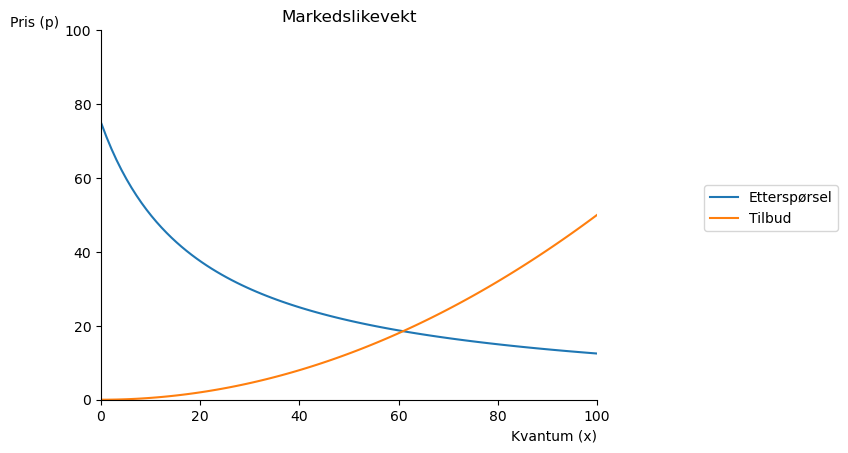

In [46]:
x_num=np.linspace(0.1,100,100)

#lag en akse

def create_ax():
                fig, ax = plt.subplots()
                ax.set_ylabel('Pris (p)', loc='top', rotation = 0)
                ax.set_xlabel('Kvantum (x)', loc='right')
                ax.set(xlim=(0,100))
                ax.set(ylim=(0,100))
                ax.spines['top'].set_color('none')
                ax.spines['right'].set_color('none')
                
                return fig, ax

fig, ax = create_ax()

# plott funksjonen

ax.plot(x_num, demand(x_num), label='Etterspørsel')
ax.plot(x_num, supply(x_num), label='Tilbud')



# tittel
ax.set_title('Markedslikevekt')

#vis navnene:
ax.legend(bbox_to_anchor=(1.5,0.6));

### Vi tegner inn likevektspris og -kvantum.

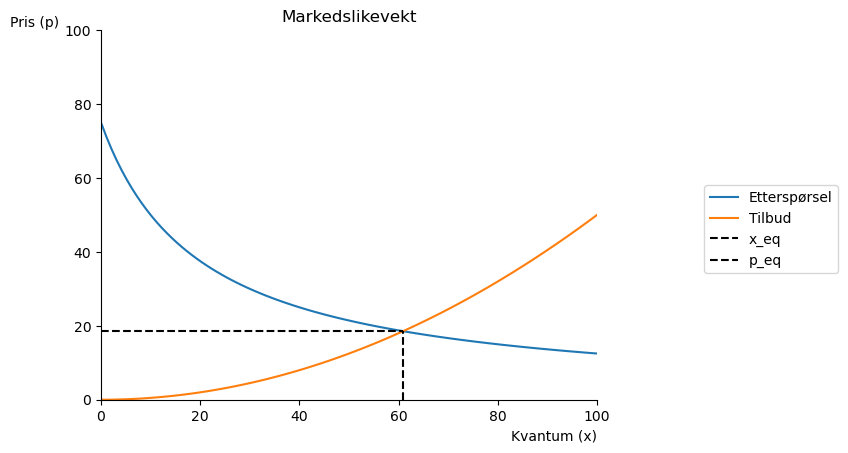

In [47]:
q = np.linspace(0,x_eq,100)

ax.vlines(x_eq,0,demand(x_eq), color='black',ls='dashed', label='x_eq')
ax.hlines(p_eq,0,x_eq, color='black',ls='dashed', label='p_eq')
ax.legend(bbox_to_anchor=(1.5,0.6))
fig


Den vertikale avstanden mellom etterspørselskurven og likevektsprisen er forskjellen i hva konsumenter er villig til å betale for hver ekstra enhet og hva de faktisk må betale. Dette er et overskudd til konsumenten, og kan summeres over alle enheter kjøpt. Dette gir oss konsumentoverskuddet som det grønne området nedenfor.

Den vertikale avstanden mellom likevektsprisen og tilbudskurven viser et overskudd for produsentene ettersom tilbudskurven angir deres grensekostnad. Det røde området i figuren nedenfor angir produsentoverskuddet. Både KO og PO er målt i pengeenheter, og summen utgjør samfunnsøkonomisk overskudd (SO = KO+PO).

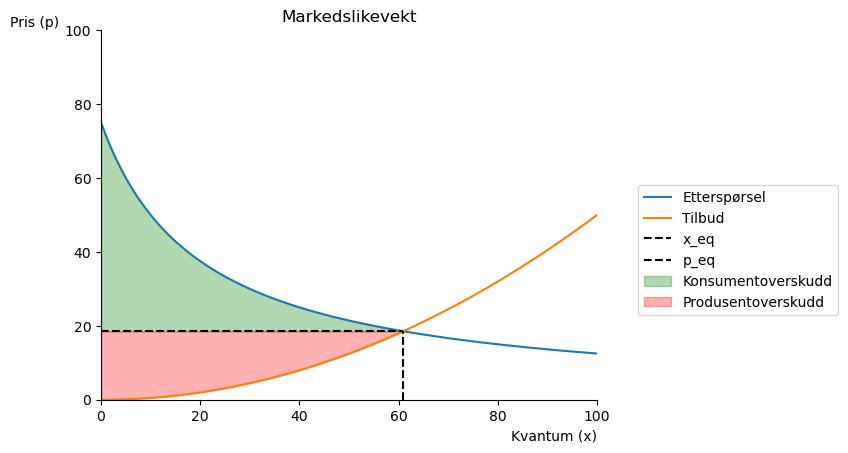

In [52]:
ax.fill_between(q,p_eq,demand(q), color = "green",alpha = 0.3,label='Konsumentoverskudd')
ax.fill_between(q,supply(q),p_eq, color = "red",alpha = 0.3,label='Produsentoverskudd')

ax.legend(bbox_to_anchor=(1.5,0.6))
fig

In [48]:
producer_surplus=sp.integrate(p_eq-supply(x),(x,0,x_eq))
producer_surplus

752.771582940749

In [49]:
consumer_surplus=sp.integrate(demand(x)-p_eq,(x,0,x_eq))
consumer_surplus


967.006531985176

In [50]:
welfare_surplus=float(sp.integrate(demand(x)-supply(x),(x,0,x_eq)))
welfare_surplus

1719.7781149259245

In [51]:
from IPython.display import Markdown, display

tbl=f"""
| Overskudd           | Verdi (kr)                               |
|---------------------|  ----------------------------------------|
| Solgt mengde:       | ${np.round(float(x_eq),2)}$              |
| Pris:               | ${np.round(float(p_eq),2)}$              |
| Konsumentoverskudd: | ${np.round(float(consumer_surplus),2)}$  | 
| Produsentoverskudd: | ${np.round(float(producer_surplus),2)}$  | 
| Samføk overskudd:   | ${np.round(float(welfare_surplus),2)}$   | 
"""
display(Markdown(tbl))


| Overskudd           | Verdi (kr)                               |
|---------------------|  ----------------------------------------|
| Solgt mengde:       | $60.9$              |
| Pris:               | $18.54$              |
| Konsumentoverskudd: | $967.01$  | 
| Produsentoverskudd: | $752.77$  | 
| Samføk overskudd:   | $1719.78$   | 
